In [17]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

# import numpy as np # linear algebra
# import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

**Import modules**

In [18]:
import os
import gc
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModelForMultipleChoice, get_linear_schedule_with_warmup



**Set up - Install Wandb**

In [19]:
!pip uninstall -y wandb
!pip install --no-cache-dir wandb==0.22.3

Found existing installation: wandb 0.22.3
Uninstalling wandb-0.22.3:
  Successfully uninstalled wandb-0.22.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.0/20.0 MB 161.5 MB/s eta 0:00:0000:0100:01


In [20]:
import wandb
import warnings
warnings.filterwarnings("ignore")

print("torch:", torch.__version__)
print("wandb:", wandb.__version__)

torch: 2.10.0+cu128
wandb: 0.22.3


**WandB login**

In [21]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
WANDB_TOKEN = user_secrets.get_secret("WANDB_TOKEN")

wandb.login(key=WANDB_TOKEN)

wandb: WARNING Calling wandb.login() after wandb.init() has no effect.


True

**Config**

In [22]:
CONFIG = {
    "model_name": "microsoft/deberta-v3-base",
    "max_len": 256,
    "batch_size": 8,
    "accum_steps": 2,          
    "epochs": 3,
    "lr": 2e-5,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "freeze_embeddings": False,
    "use_fp16": True,
    "seed": 42,
    "project": "DL-22f1000828-notebook-t22026",
    "device": torch.device('cuda' if torch.cuda.is_available() else 'cpu')
}

LABEL2IDX = {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4}
IDX2LABEL = {0: 'A', 1: 'B', 2: 'C', 3: 'D', 4: 'E'}
option_cols = ['A', 'B', 'C', 'D', 'E']

In [23]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CONFIG['seed'])
print("Device:", CONFIG['device'])
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


**Loading data**

In [24]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

# fill missing values so the tokenizer never gets a NaN
for df in [train, test]:
    for col in ['prompt'] + option_cols:
        df[col] = df[col].fillna("")

print("Train shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Train shape: (2000, 8)
Test shape: (500, 7)


,id,prompt,A,B,C,D,E,answer
0,1,Pick the best possible answer: What is Martin ...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
1,2,What is accelerator-based light-ion fusion?,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,Accelerator-based light-ion fusion is a techni...,A
2,3,Determine the correct option: What is the term...,Blueshifting,Redshifting,Reddening,Whitening,Yellowing,C
3,4,Select the most accurate option: What is Marti...,Martin Heidegger believes that humans exist wi...,Martin Heidegger believes that humans do not e...,Martin Heidegger does not believe in the exist...,Martin Heidegger believes that the relationshi...,Martin Heidegger believes that time is an illu...,B
4,5,Identify the correct statement: What is the co...,"Simultaneity is relative, meaning that two eve...","Simultaneity is relative, meaning that two eve...","Simultaneity is absolute, meaning that two eve...",Simultaneity is a concept that applies only to...,Simultaneity is a concept that applies only to...,A


**Preprocessing for the transformer**

In [25]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])
print("Tokenizer:", type(tokenizer).__name__)
print("Vocab size:", tokenizer.vocab_size)

# see what one example looks like
ex = tokenizer(train.loc[0, 'prompt'], train.loc[0, 'A'], truncation=True, max_length=64)
print()
print("Example encoding:")
print(tokenizer.decode(ex['input_ids']))

Tokenizer: DebertaV2Tokenizer
Vocab size: 128000

Example encoding:
Pick the best possible answer: What is Martin Heidegger's view on the relationship between time and human existence? among the listed options. Martin Heidegger believes that humans exist within a time continuum that is infinite and does not have a defined beginning or end. The relationship to the past involves acknowledging it as a historical era, and


In [26]:
class MCQDataset(Dataset):
    def __init__(self, df, tokenizer, max_len, is_train=True):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.is_train = is_train

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        prompt = str(row['prompt'])

        # the same prompt repeated 5 times, paired with each option
        first = [prompt] * 5
        second = [str(row[c]) for c in option_cols]

        enc = self.tokenizer(
            first,
            second,
            truncation=True,
            max_length=self.max_len,
            padding=False          # padding is done in the collate function
        )

        item = {k: v for k, v in enc.items()}
        if self.is_train:
            item['label'] = LABEL2IDX[row['answer']]
        return item

In [27]:
def collate_fn(batch):
    labels = None
    if 'label' in batch[0]:
        labels = torch.tensor([b['label'] for b in batch], dtype=torch.long)

    keys = [k for k in batch[0].keys() if k != 'label']

    # flatten: batch of 5 options -> one long list
    flat = []
    for b in batch:
        for i in range(5):
            flat.append({k: b[k][i] for k in keys})

    padded = tokenizer.pad(flat, padding=True, return_tensors='pt')

    # reshape back to (batch, 5, seq_len)
    out = {}
    for k, v in padded.items():
        out[k] = v.view(len(batch), 5, -1)

    if labels is not None:
        out['labels'] = labels
    return out

**Train validation split**

In [28]:
train_df, val_df = train_test_split(
    train,
    test_size=0.15,
    random_state=CONFIG['seed'],
    stratify=train['answer']
)
print("Train rows:", len(train_df), " Val rows:", len(val_df))

train_dataset = MCQDataset(train_df, tokenizer, CONFIG['max_len'], is_train=True)
val_dataset = MCQDataset(val_df, tokenizer, CONFIG['max_len'], is_train=True)

# check one batch
check_loader = DataLoader(train_dataset, batch_size=2, collate_fn=collate_fn)
batch = next(iter(check_loader))
for k, v in batch.items():
    print(k, v.shape)

Train rows: 1700  Val rows: 300
input_ids torch.Size([2, 5, 63])
token_type_ids torch.Size([2, 5, 63])
attention_mask torch.Size([2, 5, 63])
labels torch.Size([2])


**MAP@3 metric**

In [29]:
def map_at_3(probs, targets):
    top3 = np.argsort(-probs, axis=1)[:, :3]
    score = 0.0
    for i in range(len(targets)):
        for rank in range(3):
            if top3[i][rank] == targets[i]:
                score = score + 1.0 / (rank + 1)
                break
    return score / len(targets)

# random baseline for MAP@3 with 5 options
print("Random baseline MAP@3:", round((1 + 1/2 + 1/3) / 5, 4))

Random baseline MAP@3: 0.3667


**Optimizer with two parameter groups**

In [30]:
def build_optimizer(model, lr, weight_decay):
    no_decay = ['bias', 'LayerNorm.weight']

    decay_params = []
    no_decay_params = []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if any(nd in name for nd in no_decay):
            no_decay_params.append(param)
        else:
            decay_params.append(param)

    groups = [
        {'params': decay_params, 'weight_decay': weight_decay},
        {'params': no_decay_params, 'weight_decay': 0.0}
    ]
    print("Params with decay:", len(decay_params), "| without decay:", len(no_decay_params))
    return AdamW(groups, lr=lr)

**Training function**

In [31]:
def run_experiment(cfg, run_name):
    set_seed(cfg['seed'])
    device = cfg['device']

    train_loader = DataLoader(train_dataset, batch_size=cfg['batch_size'],
                              shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=cfg['batch_size'],
                            shuffle=False, collate_fn=collate_fn)
   

    model = AutoModelForMultipleChoice.from_pretrained(cfg['model_name'],torch_dtype=torch.float32).to(device)

    # optional: freeze the embedding layer (used in one of my experiments)
    if cfg['freeze_embeddings']:
        for param in model.deberta.embeddings.parameters():
            param.requires_grad = False
        print("Embeddings are frozen")

    optimizer = build_optimizer(model, cfg['lr'], cfg['weight_decay'])

    total_steps = len(train_loader) // cfg['accum_steps'] * cfg['epochs']
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(total_steps * cfg['warmup_ratio']),
        num_training_steps=total_steps
    )

    scaler = torch.cuda.amp.GradScaler(enabled=cfg['use_fp16'])

    wandb.init(project=cfg['project'], name=run_name,
               config={k: str(v) for k, v in cfg.items()},
               reinit=True, settings=wandb.Settings(save_code=False))

    model_path = "/kaggle/working/" + run_name + ".pth"
    best_map3 = 0.0
    best_acc = 0.0
    best_f1 = 0.0
    history = []

    print()
    print("Starting run:", run_name )

    for epoch in range(cfg['epochs']):

        # training
        
        model.train()
        train_loss = 0
        optimizer.zero_grad()

        for step, batch in enumerate(tqdm(train_loader, desc="Epoch " + str(epoch+1) + " [train]")):
            batch = {k: v.to(device) for k, v in batch.items()}

            with torch.cuda.amp.autocast(enabled=cfg['use_fp16']):
                out = model(**batch)
                loss = out.loss / cfg['accum_steps']

            scaler.scale(loss).backward()
            train_loss = train_loss + loss.item() * cfg['accum_steps']

            # only update every accum_steps batches
            if (step + 1) % cfg['accum_steps'] == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
                optimizer.zero_grad()

        train_loss = train_loss / len(train_loader)

        # validation 
        
        model.eval()
        val_loss = 0
        val_probs = []
        val_targets = []

        with torch.no_grad():
            for batch in tqdm(val_loader, desc="Epoch " + str(epoch+1) + " [val]"):
                labels = batch['labels']
                batch = {k: v.to(device) for k, v in batch.items()}

                with torch.cuda.amp.autocast(enabled=cfg['use_fp16']):
                    out = model(**batch)

                val_loss = val_loss + out.loss.item()
                probs = F.softmax(out.logits.float(), dim=1).cpu().numpy()
                val_probs.append(probs)
                val_targets.extend(labels.numpy())

        val_loss = val_loss / len(val_loader)
        val_probs = np.vstack(val_probs)
        val_targets = np.array(val_targets)
        val_preds = val_probs.argmax(axis=1)

        val_acc = accuracy_score(val_targets, val_preds)
        val_f1 = f1_score(val_targets, val_preds, average='macro')
        val_map3 = map_at_3(val_probs, val_targets)

        print("Epoch", epoch+1,
              "| train loss:", round(train_loss, 4),
              "| val loss:", round(val_loss, 4),
              "val acc:", round(val_acc, 4),
              "val map3:", round(val_map3, 4))

        wandb.log({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1,
            "val_map3": val_map3
        })

        history.append({
            "epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss,
            "val_acc": val_acc, "val_f1": val_f1, "val_map3": val_map3
        })

        if val_map3 > best_map3:
            best_map3 = val_map3
            best_acc = val_acc
            best_f1 = val_f1
            torch.save(model.state_dict(), model_path)
            print("   saved best model (val map3 =", round(val_map3, 4), ")")

    wandb.summary["best_val_acc"] = best_acc
    wandb.summary["best_val_f1"] = best_f1
    wandb.summary["best_val_map3"] = best_map3
    wandb.finish()

    del model, optimizer
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "run_name": run_name, "config": cfg, "model_path": model_path,
        "best_val_acc": best_acc, "best_val_f1": best_f1,
        "best_val_map3": best_map3, "history": history
    }

In [32]:
experiment_configs = [
    {**CONFIG, "lr": 2e-5, "freeze_embeddings": False},
    {**CONFIG, "lr": 1e-5, "freeze_embeddings": False},
    {**CONFIG, "lr": 2e-5, "freeze_embeddings": True},
]
run_names = ["deberta-lr2e5", "deberta-lr1e5", "deberta-frozen-emb"]

run_results = []
for i in range(len(experiment_configs)):
    result = run_experiment(experiment_configs[i], run_names[i])
    run_results.append(result)

print("All runs finished.")

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                

Params with decay: 76 | without decay: 126



Starting run: deberta-lr2e5


...

Epoch 2 | train loss: 1.0487 | val loss: 0.649 val acc: 0.8233 val map3: 0.8906
   saved best model (val map3 = 0.8906 )


Epoch 3 [val]: 100%|██████████| 38/38 [00:03<00:00, 10.53it/s]


Epoch 3 | train loss: 0.8041 | val loss: 0.5594 val acc: 0.86 val map3: 0.92
   saved best model (val map3 = 0.92 )


epoch,▁▅█
train_loss,█▃▁
val_acc,▁▇█
val_f1,▁▇█
val_loss,█▂▁
val_map3,▁▇█
best_val_acc,0.86
best_val_f1,0.8595
best_val_map3,0.92
epoch,3
train_loss,0.80409


All runs finished.


**Compare the runs**

             run_name       lr  frozen_emb   val_acc    val_f1  val_map3
2  deberta-frozen-emb  0.00002        True  0.860000  0.859498  0.920000
1       deberta-lr1e5  0.00001       False  0.396667  0.396307  0.571111
0       deberta-lr2e5  0.00002       False  0.230000  0.184832  0.403889


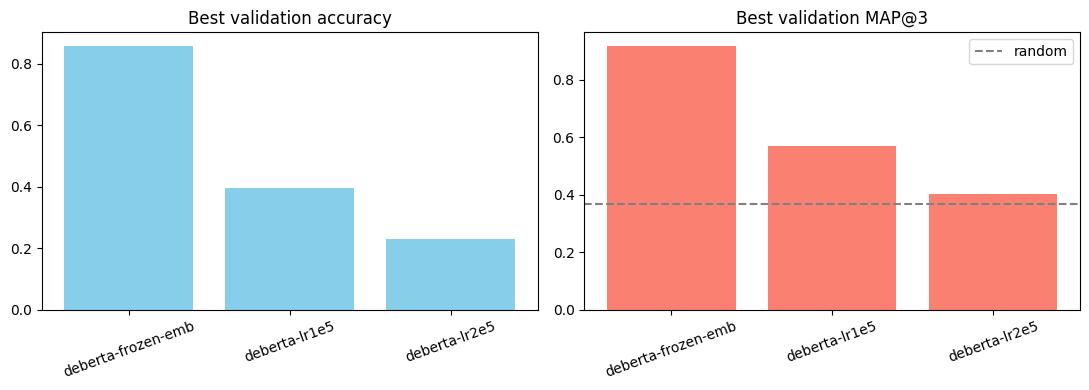


Best run: deberta-frozen-emb val map3 = 0.92


In [33]:
rows = []
for r in run_results:
    rows.append({
        "run_name": r["run_name"],
        "lr": r["config"]["lr"],
        "frozen_emb": r["config"]["freeze_embeddings"],
        "val_acc": r["best_val_acc"],
        "val_f1": r["best_val_f1"],
        "val_map3": r["best_val_map3"],
    })

comparison_df = pd.DataFrame(rows).sort_values("val_map3", ascending=False)
print(comparison_df)

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.bar(comparison_df["run_name"], comparison_df["val_acc"], color='skyblue')
plt.title("Best validation accuracy")
plt.xticks(rotation=20)

plt.subplot(1, 2, 2)
plt.bar(comparison_df["run_name"], comparison_df["val_map3"], color='salmon')
plt.axhline(0.3667, color='gray', linestyle='--', label='random')
plt.title("Best validation MAP@3")
plt.xticks(rotation=20)
plt.legend()

plt.tight_layout()
plt.show()

best_run = run_results[0]
for r in run_results:
    if r["best_val_map3"] > best_run["best_val_map3"]:
        best_run = r

print()
print("Best run:", best_run["run_name"], "val map3 =", round(best_run["best_val_map3"], 4))

**Learning curves**

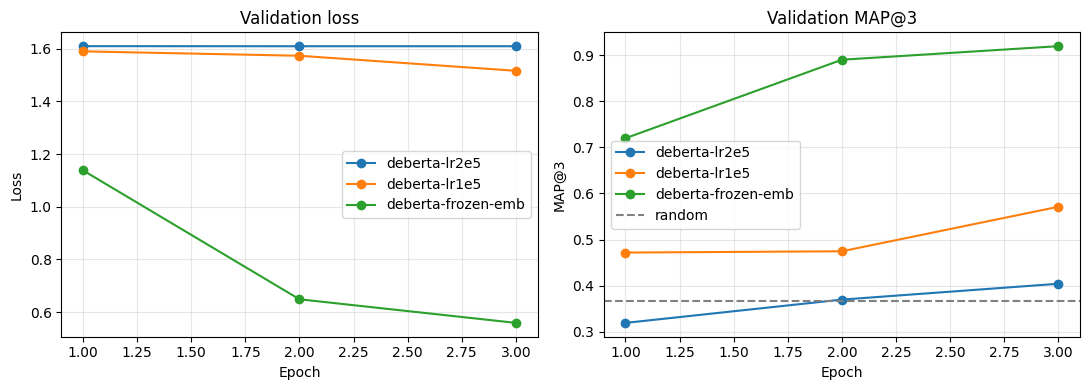

In [34]:
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
for r in run_results:
    h = pd.DataFrame(r["history"])
    plt.plot(h["epoch"], h["val_loss"], marker='o', label=r["run_name"])
plt.title("Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for r in run_results:
    h = pd.DataFrame(r["history"])
    plt.plot(h["epoch"], h["val_map3"], marker='o', label=r["run_name"])
plt.axhline(0.3667, color='gray', linestyle='--', label='random')
plt.title("Validation MAP@3")
plt.xlabel("Epoch")
plt.ylabel("MAP@3")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Inference**

In [35]:
def predict(model_path, cfg, dataset):
    model = AutoModelForMultipleChoice.from_pretrained(cfg['model_name'])
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model.to(cfg['device'])
    model.eval()

    loader = DataLoader(dataset, batch_size=cfg['batch_size'],
                        shuffle=False, collate_fn=collate_fn)

    all_probs = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Predicting"):
            batch = {k: v.to(cfg['device']) for k, v in batch.items() if k != 'labels'}
            with torch.cuda.amp.autocast(enabled=cfg['use_fp16']):
                out = model(**batch)
            all_probs.append(F.softmax(out.logits.float(), dim=1).cpu().numpy())

    del model
    gc.collect()
    torch.cuda.empty_cache()
    return np.vstack(all_probs)

In [36]:
# first check on validation: is the ensemble better than the single best model?
val_targets = np.array([LABEL2IDX[a] for a in val_df['answer']])

val_probs_list = []
for r in run_results:
    p = predict(r["model_path"], r["config"], val_dataset)
    val_probs_list.append(p)
    print(r["run_name"], "val map3:", round(map_at_3(p, val_targets), 4))

ensemble_val = np.mean(val_probs_list, axis=0)
ensemble_score = map_at_3(ensemble_val, val_targets)
single_score = best_run["best_val_map3"]

print()
print("Single best model val MAP@3:", round(single_score, 4))
print("Ensemble of 3 val MAP@3   :", round(ensemble_score, 4))

use_ensemble = ensemble_score > single_score
print("Using ensemble:", use_ensemble)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                

deberta-lr2e5 val map3: 0.3733


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                

deberta-lr1e5 val map3: 0.5694


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                

deberta-frozen-emb val map3: 0.9178

Single best model val MAP@3: 0.92
Ensemble of 3 val MAP@3   : 0.9017
Using ensemble: False


In [37]:
test_dataset = MCQDataset(test, tokenizer, CONFIG['max_len'], is_train=False)

if use_ensemble:
    probs_list = []
    for r in run_results:
        probs_list.append(predict(r["model_path"], r["config"], test_dataset))
    all_probs = np.mean(probs_list, axis=0)
else:
    all_probs = predict(best_run["model_path"], best_run["config"], test_dataset)

# top 3 in ranked order, because the metric is MAP@3
top3 = np.argsort(-all_probs, axis=1)[:, :3]

predictions = []
for row in top3:
    predictions.append(IDX2LABEL[row[0]] + " " + IDX2LABEL[row[1]] + " " + IDX2LABEL[row[2]])

submission = pd.DataFrame({'ID': test['id'], 'Prediction': predictions})
submission.to_csv("submission.csv", index=False)

print("submission.csv created, shape:", submission.shape)
print(submission.head())

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2ForMultipleChoice LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     | 
----------------------------------------+------------+-
mask_predictions.classifier.bias        | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPECTED | 
pooler.dense.weight                     | MISSING    | 
pooler.dense.bias                       | MISSING    | 
classifier.bias                         | MISSING    | 
classifier.weight                

submission.csv created, shape: (500, 2)
   ID Prediction
0   1      A E D
1   2      B D C
2   3      B E D
3   4      E C A
4   5      C D A


**Check for prediction**

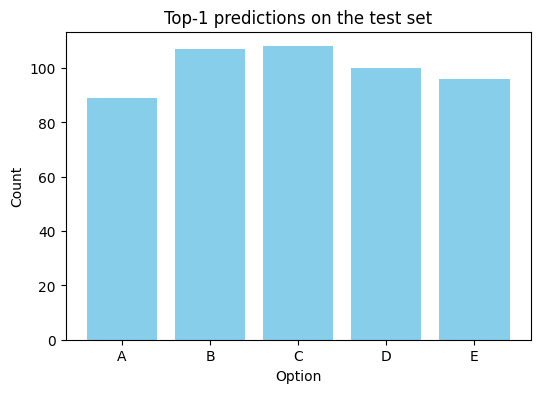

A     89
B    107
C    108
D    100
E     96
Name: count, dtype: int64



In [38]:
first_choice = [p.split()[0] for p in predictions]
counts = pd.Series(first_choice).value_counts().reindex(option_cols, fill_value=0)

plt.figure(figsize=(6, 4))
plt.bar(counts.index, counts.values, color='skyblue')
plt.title("Top-1 predictions on the test set")
plt.xlabel("Option")
plt.ylabel("Count")
plt.show()

print(counts)
print()
